# 🧠 autograd-numpy: Backprop From Scratch
### A 2-layer MLP on MNIST with every gradient coded by hand in NumPy

**What you'll do in this notebook**

| Part | What happens |
|---|---|
| 1 | Setup + load MNIST (works on Kaggle, Colab, or your laptop) |
| 2 | Build `Linear` and `ReLU` layers with hand-derived backward passes |
| 3 | Build the fused, numerically stable softmax cross-entropy loss |
| 4 | Assemble the MLP and **prove** the gradients correct with finite differences |
| 5 | Write SGD and Adam from scratch |
| 6 | Train, compare, and inspect what the network learned |
| 7 | Break things on purpose, then review interview answers |

**The one-sentence story:** every training step is *guess → measure the error → trace the blame backwards → nudge the weights*. Frameworks hide the third step. Here we do it ourselves.

---
## Part 1 · Setup and data

### 1.1 Configuration and helpers
All the knobs live in one cell. `OUT_DIR` automatically points to `/kaggle/working` when running on Kaggle (so your outputs show up in the *Output* tab) and to `results/` elsewhere.

In [1]:
import os, gzip, time, json, socket, urllib.request
import numpy as np
import matplotlib.pyplot as plt

SEED       = 0                                   # one seed => reproducible runs
EPOCHS     = int(os.environ.get("EPOCHS", 10))   # full passes over the training set
BATCH_SIZE = 64
HIDDEN     = 128                                 # hidden-layer width
LR_SGD     = 0.1
LR_ADAM    = 1e-3

OUT_DIR = "/kaggle/working" if os.path.isdir("/kaggle/working") else "results"
os.makedirs(OUT_DIR, exist_ok=True)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

def show(fig, name):
    """Save a figure to OUT_DIR and display it."""
    fig.tight_layout()
    fig.savefig(os.path.join(OUT_DIR, name), dpi=140)
    plt.show()

### 1.2 The data loader
Images are 28×28 pixels. We flatten each into a vector of **784 numbers in [0, 1]**, because our first layer is a matrix multiplication.

The loader tries these sources in order, so the same file works almost anywhere:
1. **Kaggle-attached MNIST** (IDX files) under `/kaggle/input` 
2. **Kaggle CSV** versions (`mnist_train.csv` / `mnist_test.csv`, or the *Digit Recognizer* `train.csv`)
3. **Download** from a public mirror (needs internet; on Kaggle, enable *Settings → Internet*)
4. **Fallback:** scikit-learn's tiny 8×8 `digits` set, so the notebook still runs offline (expect ~90% accuracy, not ~97%)

In [3]:
MIRROR = "https://ossci-datasets.s3.amazonaws.com/mnist/"
IDX = {"x_train": "train-images-idx3-ubyte", "y_train": "train-labels-idx1-ubyte",
       "x_test":  "t10k-images-idx3-ubyte",  "y_test":  "t10k-labels-idx1-ubyte"}

def _read_bytes(path):
    opener = gzip.open if path.endswith(".gz") else open
    with opener(path, "rb") as f:
        return f.read()

def _idx(buf, is_image):
    # IDX format: 16-byte header for images, 8-byte header for labels, then raw uint8s
    arr = np.frombuffer(buf, dtype=np.uint8, offset=16 if is_image else 8)
    return arr.reshape(-1, 784) if is_image else arr

def _from_idx_paths(p):
    xtr = _idx(_read_bytes(p["x_train"]), True).astype(np.float64) / 255.0
    xte = _idx(_read_bytes(p["x_test"]),  True).astype(np.float64) / 255.0
    ytr = _idx(_read_bytes(p["y_train"]), False).astype(np.int64)
    yte = _idx(_read_bytes(p["y_test"]),  False).astype(np.int64)
    return xtr, ytr, xte, yte

def _list_files(root):
    return [os.path.join(d, f) for d, _, fs in os.walk(root) for f in fs]

def _pick(files, *keys):
    for p in files:
        n = os.path.basename(p).lower().replace(".", "-").replace("_", "-")
        if "idx" in n and all(k in n for k in keys):
            return p
    return None

def _try_kaggle_idx():
    if not os.path.isdir("/kaggle/input"):
        return None
    f = _list_files("/kaggle/input")
    p = {"x_train": _pick(f, "train", "images"), "y_train": _pick(f, "train", "labels"),
         "x_test":  _pick(f, "t10k", "images"),  "y_test":  _pick(f, "t10k", "labels")}
    return _from_idx_paths(p) if all(p.values()) else None

def _read_csv(path):
    try:
        import pandas as pd
        return pd.read_csv(path).values.astype(np.float64)
    except ImportError:
        return np.loadtxt(path, delimiter=",", skiprows=1)

def _split_xy(a):                       # first column = label, rest = 784 pixels
    return a[:, 1:] / 255.0, a[:, 0].astype(np.int64)

def _try_kaggle_csv():
    if not os.path.isdir("/kaggle/input"):
        return None
    by = {os.path.basename(p).lower(): p for p in _list_files("/kaggle/input")}
    if "mnist_train.csv" in by and "mnist_test.csv" in by:
        xtr, ytr = _split_xy(_read_csv(by["mnist_train.csv"]))
        xte, yte = _split_xy(_read_csv(by["mnist_test.csv"]))
        return xtr, ytr, xte, yte
    if "train.csv" in by:               # Digit Recognizer competition: only train has labels
        a = _read_csv(by["train.csv"])
        if a.shape[1] == 785:
            a = a[np.random.default_rng(SEED).permutation(len(a))]
            cut = int(0.85 * len(a))
            xtr, ytr = _split_xy(a[:cut]); xte, yte = _split_xy(a[cut:])
            return xtr, ytr, xte, yte
    return None

def _try_download(cache="data"):
    try:
        socket.setdefaulttimeout(20)
        os.makedirs(cache, exist_ok=True)
        p = {}
        for key, name in IDX.items():
            dest = os.path.join(cache, name + ".gz")
            if not os.path.exists(dest):
                print(f"Downloading {name} ...")
                urllib.request.urlretrieve(MIRROR + name + ".gz", dest)
            p[key] = dest
        return _from_idx_paths(p)
    except Exception as e:
        print("Download unavailable:", type(e).__name__)
        return None

def _digits_fallback():
    from sklearn.datasets import load_digits
    d = load_digits()
    idx = np.random.default_rng(SEED).permutation(len(d.data))
    x, y = d.data[idx] / 16.0, d.target[idx].astype(np.int64)
    cut = int(0.8 * len(x))
    return x[:cut], y[:cut], x[cut:], y[cut:]

def load_data():
    for name, fn in [("Kaggle IDX", _try_kaggle_idx), ("Kaggle CSV", _try_kaggle_csv),
                     ("download", _try_download)]:
        data = fn()
        if data is not None:
            return data, f"MNIST via {name}"
    print("⚠️  MNIST unavailable -> using small 8x8 digits fallback (accuracy will be lower).")
    return _digits_fallback(), "sklearn digits (8x8) fallback"

data, SOURCE = load_data()
x_train, y_train, x_test, y_test = data
IN_DIM = x_train.shape[1]
SIDE = int(round(np.sqrt(IN_DIM)))
print(f"Source: {SOURCE}")
print(f"train: {x_train.shape}  test: {x_test.shape}  pixel range: [{x_train.min():.1f}, {x_train.max():.1f}]")

Source: MNIST via download
train: (60000, 784)  test: (10000, 784)  pixel range: [0.0, 1.0]


### 1.3 Look at the data first
Always look at your data before modelling. It catches loading bugs (scrambled images, wrong labels) immediately.

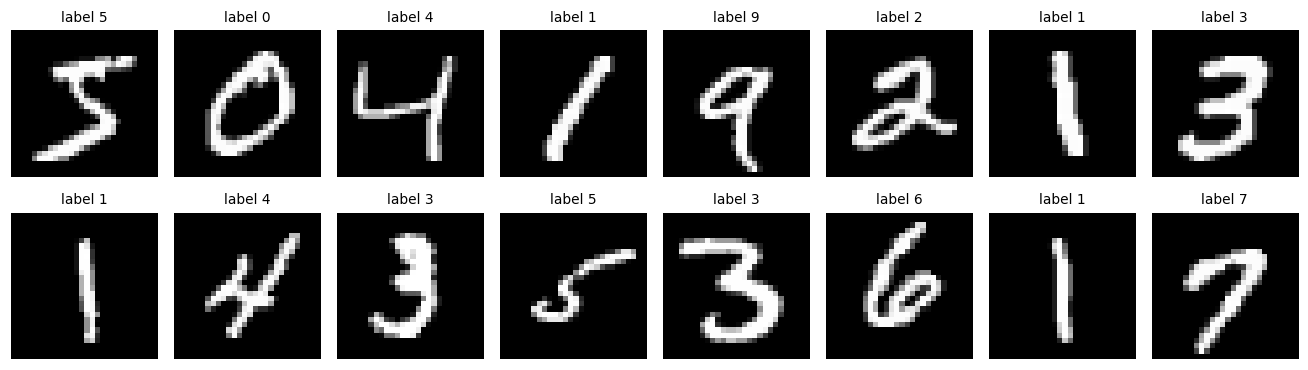

class balance: [5923 6742 5958 6131 5842 5421 5918 6265 5851 5949]


In [5]:
fig, axes = plt.subplots(2, 8, figsize=(12, 3.6))
for ax, i in zip(axes.ravel(), range(16)):
    ax.imshow(x_train[i].reshape(SIDE, SIDE), cmap="gray"); ax.set_title(f"label {y_train[i]}", fontsize=9); ax.axis("off")
show(fig, "samples.png")
print("class balance:", np.bincount(y_train))

---
## Part 2 · Layers: forward and backward by hand

### 2.1 Theory: the chain rule is the whole idea
Our network computes
$$H = \mathrm{ReLU}(XW_1 + b_1),\qquad Z = HW_2 + b_2,\qquad L = \mathrm{CE}(\mathrm{softmax}(Z), y)$$

To train it we need $\partial L/\partial W_1,\ \partial L/\partial b_1,\ \partial L/\partial W_2,\ \partial L/\partial b_2$. The chain rule lets each layer work **locally**:

> A layer receives $\partial L/\partial(\text{its output})$, uses its own local derivative, and passes $\partial L/\partial(\text{its input})$ to the layer below.

So every layer needs just two methods: `forward` (which **caches** what the backward pass will need) and `backward`.

### 2.2 The Linear layer
$Y = XW + b$ with shapes $X:(N,\text{in})$, $W:(\text{in},\text{out})$, $b:(\text{out},)$, $Y:(N,\text{out})$.

Element-wise: $Y_{nj} = \sum_i X_{ni}W_{ij} + b_j$. Differentiating:

| Want | Formula | Why |
|---|---|---|
| $\partial L/\partial W$ | $X^\top\,dY$ | $W_{ij}$ touched $Y_{nj}$ with weight $X_{ni}$, summed over samples |
| $\partial L/\partial b$ | $\sum_n dY_{n\cdot}$ | the bias is added with weight 1 to every sample |
| $\partial L/\partial X$ | $dY\,W^\top$ | $X_{ni}$ touched $Y_{nj}$ through $W_{ij}$ |

💡 **Shape check:** $X^\top dY$ is $(\text{in},N)(N,\text{out}) = (\text{in},\text{out})$, which is exactly the shape of $W$. If shapes don't match, the derivation is wrong.

**He initialization.** Each output sums `in` terms, so unscaled weights make the signal grow by about `in`× per layer. Scaling by $\sqrt{2/\text{in}}$ keeps variance stable (the 2 compensates for ReLU zeroing half the signal).

In [7]:
class Linear:
    """Y = X @ W + b"""
    def __init__(self, in_features, out_features, rng):
        self.W = rng.standard_normal((in_features, out_features)) * np.sqrt(2.0 / in_features)  # He init
        self.b = np.zeros(out_features)
        self.dW = np.zeros_like(self.W)
        self.db = np.zeros_like(self.b)
        self._x = None                         # cache slot

    def forward(self, x):
        self._x = x                            # breadcrumb for the backward pass
        return x @ self.W + self.b             # broadcasting adds b to every row

    def backward(self, dout):
        self.dW = self._x.T @ dout             # dL/dW = X^T dY
        self.db = dout.sum(axis=0)             # dL/db = sum of dY over the batch
        return dout @ self.W.T                 # dL/dX = dY W^T  -> baton to previous layer

    def parameters(self):
        return [(self.W, self.dW), (self.b, self.db)]   # live arrays, so optimizers can edit in place

In [9]:
# Quick shape sanity check
rng = np.random.default_rng(0)
lin = Linear(IN_DIM, HIDDEN, rng)
out = lin.forward(x_train[:64])
back = lin.backward(np.ones_like(out))
print("forward  out:", out.shape)
print("backward dW :", lin.dW.shape, "(matches W:", lin.W.shape, ")")
print("backward db :", lin.db.shape, " dX:", back.shape, "(matches X:", x_train[:64].shape, ")")

forward  out: (64, 128)
backward dW : (784, 128) (matches W: (784, 128) )
backward db : (128,)  dX: (64, 784) (matches X: (64, 784) )


### 2.3 ReLU: the decision gate
Without a nonlinearity, stacked linear layers collapse into one linear layer. ReLU is $\max(0,x)$.

Its derivative is **1 where $x>0$, else 0**: blame flows through neurons that fired and is blocked at the ones that didn't. We store a boolean mask in `forward` to remember which is which.

In [11]:
class ReLU:
    """Y = max(0, X)"""
    def __init__(self):
        self._mask = None

    def forward(self, x):
        self._mask = x > 0                     # True where the neuron "fired"
        return x * self._mask                  # True/False act as 1/0

    def backward(self, dout):
        return dout * self._mask               # gradient only passes where input > 0

    def parameters(self):
        return []                              # nothing to learn, but keeps the interface uniform

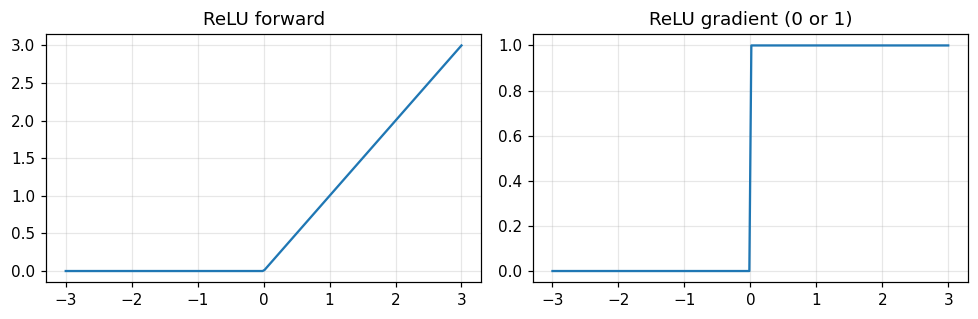

In [13]:
# Visualize ReLU's forward and its gradient
xs = np.linspace(-3, 3, 200)
r = ReLU(); y_relu = r.forward(xs); g_relu = r.backward(np.ones_like(xs))
fig, ax = plt.subplots(1, 2, figsize=(9, 3))
ax[0].plot(xs, y_relu); ax[0].set_title("ReLU forward")
ax[1].plot(xs, g_relu); ax[1].set_title("ReLU gradient (0 or 1)")
show(fig, "relu.png")

---
## Part 3 · The loss: softmax + cross-entropy

### 3.1 Theory
The last layer outputs **logits** $z$: ten raw scores per image.

* **Softmax** turns scores into probabilities: $p_k = \dfrac{e^{z_k}}{\sum_j e^{z_j}}$
* **Cross-entropy** punishes low probability on the right answer: $L = -\log p_y$

**Deriving the gradient.** For the true class $y$: $\partial L/\partial z_y = p_y - 1$. For any other class $k$: $\partial L/\partial z_k = p_k$. Combined:
$$\boxed{\frac{\partial L}{\partial z} = p - \text{onehot}(y)}$$
(divided by $N$ because our loss is a batch mean). The $1/p$ from the log cancels the $p(1-p)$ from softmax, which is the real reason these two are fused.

**Numerical stability.** $e^{1000}$ overflows. Softmax is unchanged if you subtract a constant from all logits, so we subtract the row max. And we compute $\log p_k = z_k - \log\sum_j e^{z_j}$ directly (log-sum-exp), so we never take `log(0)`.

In [15]:
def softmax_cross_entropy(logits, y):
    """Fused softmax + CE. Returns (mean loss, dL/dlogits)."""
    n = logits.shape[0]
    z = logits - logits.max(axis=1, keepdims=True)                 # stability shift
    log_probs = z - np.log(np.exp(z).sum(axis=1, keepdims=True))   # log-softmax via log-sum-exp
    loss = -log_probs[np.arange(n), y].mean()                      # pick log p of the correct class

    grad = np.exp(log_probs)                                       # p
    grad[np.arange(n), y] -= 1.0                                   # p - onehot(y)
    grad /= n                                                      # loss is a mean over the batch
    return loss, grad

### 3.2 Worked example (matches the hand calculation)
Logits `[2.0, 1.0, 0.1]` with true class 0 should give probabilities ≈ `[0.659, 0.242, 0.099]` and loss ≈ `0.417`.

In [17]:
loss, grad = softmax_cross_entropy(np.array([[2.0, 1.0, 0.1]]), np.array([0]))
print(f"loss = {loss:.3f}   (hand calc: -ln(0.659) = 0.417)")
print("grad =", np.round(grad[0], 3), "  <- p - onehot: push the right class UP (negative), the wrong ones DOWN")
print("row sums to", round(grad.sum(), 12), "(always 0 for softmax-CE)")

# Stability: naive softmax overflows, ours doesn't
big = np.array([[1000.0, 0.0, -1000.0]])
with np.errstate(all="ignore"):
    naive = np.exp(big) / np.exp(big).sum()
print("\nnaive softmax on [1000, 0, -1000]:", naive)
print("ours (loss, finite?):", softmax_cross_entropy(big, np.array([0]))[0],
      np.isfinite(softmax_cross_entropy(big, np.array([0]))[1]).all())

loss = 0.417   (hand calc: -ln(0.659) = 0.417)
grad = [-0.341  0.242  0.099]   <- p - onehot: push the right class UP (negative), the wrong ones DOWN
row sums to -0.0 (always 0 for softmax-CE)

naive softmax on [1000, 0, -1000]: [[nan  0.  0.]]
ours (loss, finite?): -0.0 True


---
## Part 4 · The model, and proof that our gradients are right

### 4.1 Assemble the MLP
`forward` pipes data through the layers in order. **`backward` is the chain rule in four lines**: walk the layers in reverse, handing each one the gradient from above.

In [19]:
class MLP:
    """Linear -> ReLU -> Linear   (the 2-layer MLP)."""
    def __init__(self, in_dim=784, hidden=128, out_dim=10, seed=0):
        rng = np.random.default_rng(seed)       # ONE rng shared by both layers: different numbers, one seed
        self.layers = [Linear(in_dim, hidden, rng), ReLU(), Linear(hidden, out_dim, rng)]

    def forward(self, x):
        for layer in self.layers:
            x = layer.forward(x)
        return x

    def backward(self, dout):
        for layer in reversed(self.layers):     # <-- backpropagation
            dout = layer.backward(dout)
        return dout

    def parameters(self):
        return [pg for layer in self.layers for pg in layer.parameters()]

    def predict(self, x):
        return self.forward(x).argmax(axis=1)   # softmax is monotonic, so argmax of logits is enough

    def n_params(self):
        return sum(p.size for p, _ in self.parameters())

    def save(self, path):
        np.savez(path, *[p for p, _ in self.parameters()])

    def load(self, path):
        d = np.load(path)
        for (p, _), k in zip(self.parameters(), d.files):
            p[...] = d[k]                       # in-place copy keeps references valid

m = MLP(IN_DIM, HIDDEN, 10, seed=SEED)
print(f"Architecture: {IN_DIM} -> {HIDDEN} -> 10   |   parameters: {m.n_params():,}")
print("untrained loss:", round(softmax_cross_entropy(m.forward(x_train[:512]), y_train[:512])[0], 3),
      "(random guessing over 10 classes = ln 10 =", round(np.log(10), 3), ")")

Architecture: 784 -> 128 -> 10   |   parameters: 101,770
untrained loss: 2.374 (random guessing over 10 classes = ln 10 = 2.303 )


### 4.2 Gradient checking: the lie detector
A sign error in a gradient never crashes anything; the network just learns badly and you never know why. We need an independent check.

The definition of a derivative is "how much does the output change when I nudge the input?", so we measure it directly with a **central difference**:
$$\frac{\partial L}{\partial\theta}\approx\frac{L(\theta+h)-L(\theta-h)}{2h}$$
This uses no calculus, so it can't share our bugs. We run it on a tiny model (it needs two forward passes *per parameter*).

In [21]:
def gradient_check(h=1e-5, grad_scale=1.0):
    rng = np.random.default_rng(1)
    x = rng.standard_normal((8, 12)); y = rng.integers(0, 4, 8)
    model = MLP(12, 7, 4, seed=3)

    _, dlogits = softmax_cross_entropy(model.forward(x), y)
    model.backward(dlogits * grad_scale)                      # grad_scale != 1 simulates a bug
    analytic = [g.copy() for _, g in model.parameters()]

    worst = 0.0
    for name, (p, _), g in zip(["W1", "b1", "W2", "b2"], model.parameters(), analytic):
        num = np.zeros_like(p)
        it = np.nditer(p, flags=["multi_index"])
        for _ in it:
            i = it.multi_index; old = p[i]
            p[i] = old + h; lp = softmax_cross_entropy(model.forward(x), y)[0]
            p[i] = old - h; lm = softmax_cross_entropy(model.forward(x), y)[0]
            p[i] = old                                         # ALWAYS restore
            num[i] = (lp - lm) / (2 * h)
        rel = np.abs(num - g).max() / (np.abs(num).max() + np.abs(g).max() + 1e-12)
        worst = max(worst, rel)
        print(f"  {name}: relative error = {rel:.2e}  {'✅' if rel < 1e-6 else '❌'}")
    return worst

print("Our backprop vs numerical gradients:")
assert gradient_check() < 1e-6
print("\nAll gradients verified ✅")

Our backprop vs numerical gradients:
  W1: relative error = 2.54e-11  ✅
  b1: relative error = 2.75e-11  ✅
  W2: relative error = 2.16e-11  ✅
  b2: relative error = 1.81e-11  ✅

All gradients verified ✅


---
## Part 5 · Optimizers from scratch

Gradients tell us the *direction of blame*; the optimizer decides *how far to move*.

**SGD:** $\theta \leftarrow \theta - \eta\, g$ (optionally with momentum $v \leftarrow \mu v + g$).

**Adam** keeps two running averages per parameter:
$$m \leftarrow \beta_1 m + (1-\beta_1)g \qquad v \leftarrow \beta_2 v + (1-\beta_2)g^2$$
$$\hat m = \frac{m}{1-\beta_1^t},\quad \hat v = \frac{v}{1-\beta_2^t},\quad \theta \leftarrow \theta - \eta\,\frac{\hat m}{\sqrt{\hat v}+\epsilon}$$

* $m$ is a smoothed direction (momentum). $v$ measures typical gradient size, and dividing by $\sqrt{v}$ gives every parameter a similar step size.
* **Bias correction:** $m,v$ start at 0, so early on they are biased low. At step 1, $m = 0.1g$; dividing by $1-0.9^1 = 0.1$ restores $g$. The correction fades as $t$ grows.

⚠️ Updates must be **in place** (`p -= ...`). Writing `p = p - ...` rebinds a local name and the model silently never learns.

In [23]:
class SGD:
    def __init__(self, lr=0.1, momentum=0.0):
        self.lr, self.momentum, self._v = lr, momentum, None

    def step(self, params_and_grads):
        if self._v is None:
            self._v = [np.zeros_like(p) for p, _ in params_and_grads]
        for v, (p, g) in zip(self._v, params_and_grads):
            v[...] = self.momentum * v + g
            p -= self.lr * v                                   # in place!


class Adam:
    def __init__(self, lr=1e-3, beta1=0.9, beta2=0.999, eps=1e-8):
        self.lr, self.b1, self.b2, self.eps = lr, beta1, beta2, eps
        self.t, self._m, self._v = 0, None, None

    def step(self, params_and_grads):
        if self._m is None:
            self._m = [np.zeros_like(p) for p, _ in params_and_grads]
            self._v = [np.zeros_like(p) for p, _ in params_and_grads]
        self.t += 1
        for m, v, (p, g) in zip(self._m, self._v, params_and_grads):
            m[...] = self.b1 * m + (1 - self.b1) * g
            v[...] = self.b2 * v + (1 - self.b2) * g * g
            m_hat = m / (1 - self.b1 ** self.t)                # bias correction
            v_hat = v / (1 - self.b2 ** self.t)
            p -= self.lr * m_hat / (np.sqrt(v_hat) + self.eps)

---
## Part 6 · Training

### 6.1 The training loop
Every iteration is the same five lines: **forward → loss → backward → update → record**. We shuffle each epoch so batches aren't correlated, and use mini-batches as the compromise between noisy (1 sample) and slow (all samples) gradients.

In [25]:
def accuracy(model, x, y):
    return float((model.predict(x) == y).mean())

def fit(model, opt, data, epochs=10, batch_size=64, seed=0, log=print):
    xtr, ytr, xte, yte = data
    rng = np.random.default_rng(seed)
    hist = {"iter_loss": [], "epoch_loss": [], "test_acc": []}
    for epoch in range(1, epochs + 1):
        idx = rng.permutation(len(xtr))                        # new order every epoch
        losses = []
        for i in range(0, len(idx), batch_size):
            b = idx[i:i + batch_size]
            logits = model.forward(xtr[b])                     # 1. guess
            loss, dlogits = softmax_cross_entropy(logits, ytr[b])  # 2. judge
            model.backward(dlogits)                            # 3. assign blame
            opt.step(model.parameters())                       # 4. correct
            losses.append(loss)                                # 5. record
        hist["iter_loss"].extend(losses)
        hist["epoch_loss"].append(float(np.mean(losses)))
        hist["test_acc"].append(accuracy(model, xte, yte))
        log(f"epoch {epoch:2d} | loss {hist['epoch_loss'][-1]:.4f} | test acc {hist['test_acc'][-1]:.4f}")
    return hist

### 6.2 SGD vs Adam, fair fight
Same seed => identical starting weights and identical batch order. The *only* difference is the optimizer.

In [27]:
results = {}
for name, make_opt in {"SGD": lambda: SGD(LR_SGD), "Adam": lambda: Adam(LR_ADAM)}.items():
    print(f"\n=== {name} ===")
    model = MLP(IN_DIM, HIDDEN, 10, seed=SEED)
    t0 = time.time()
    hist = fit(model, make_opt(), data, EPOCHS, BATCH_SIZE, SEED)
    hist["seconds"] = time.time() - t0
    results[name] = (model, hist)
    model.save(os.path.join(OUT_DIR, f"weights_{name.lower()}.npz"))
    print(f"time: {hist['seconds']:.1f}s")


=== SGD ===
epoch  1 | loss 0.3615 | test acc 0.9399
epoch  2 | loss 0.1899 | test acc 0.9503
epoch  3 | loss 0.1435 | test acc 0.9638
epoch  4 | loss 0.1171 | test acc 0.9665
epoch  5 | loss 0.0988 | test acc 0.9720
epoch  6 | loss 0.0858 | test acc 0.9734
epoch  7 | loss 0.0757 | test acc 0.9734
epoch  8 | loss 0.0678 | test acc 0.9747
epoch  9 | loss 0.0611 | test acc 0.9757
epoch 10 | loss 0.0552 | test acc 0.9765
time: 10.3s

=== Adam ===
epoch  1 | loss 0.2923 | test acc 0.9518
epoch  2 | loss 0.1301 | test acc 0.9671
epoch  3 | loss 0.0909 | test acc 0.9747
epoch  4 | loss 0.0696 | test acc 0.9747
epoch  5 | loss 0.0551 | test acc 0.9771
epoch  6 | loss 0.0451 | test acc 0.9770
epoch  7 | loss 0.0358 | test acc 0.9757
epoch  8 | loss 0.0295 | test acc 0.9769
epoch  9 | loss 0.0257 | test acc 0.9799
epoch 10 | loss 0.0196 | test acc 0.9755
time: 32.0s


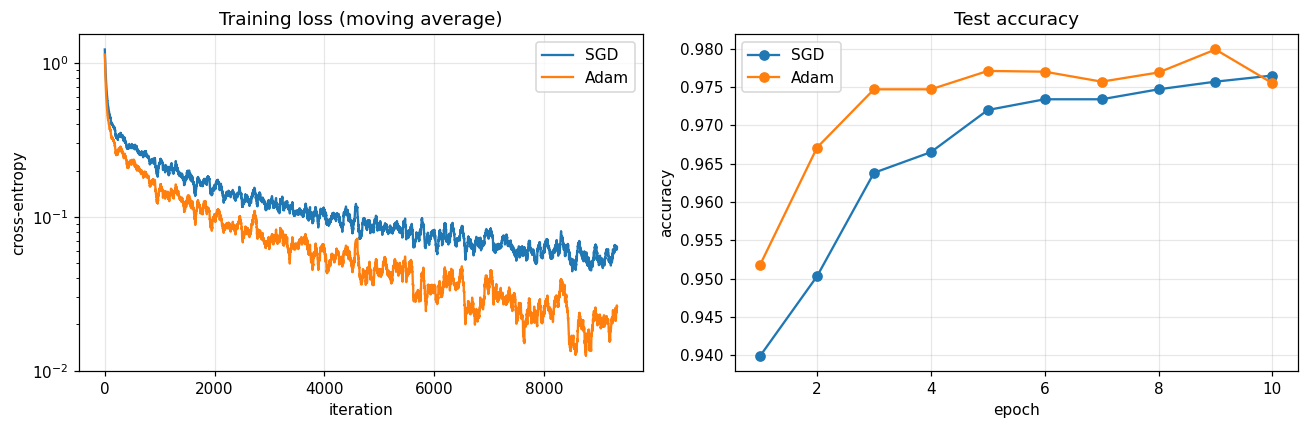

SGD   -> test acc 0.9765 | loss 0.0552 | 10.3s
Adam  -> test acc 0.9755 | loss 0.0196 | 32.0s


In [28]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for name, (_, h) in results.items():
    k = min(50, len(h["iter_loss"]))
    ax[0].plot(np.convolve(h["iter_loss"], np.ones(k) / k, mode="valid"), label=name)
    ax[1].plot(range(1, len(h["test_acc"]) + 1), h["test_acc"], marker="o", label=name)
ax[0].set(title="Training loss (moving average)", xlabel="iteration", ylabel="cross-entropy", yscale="log")
ax[1].set(title="Test accuracy", xlabel="epoch", ylabel="accuracy")
for a in ax: a.legend()
show(fig, "curves.png")

summary = {n: {"final_test_acc": h["test_acc"][-1], "final_epoch_loss": h["epoch_loss"][-1], "seconds": round(h["seconds"], 1)}
           for n, (_, h) in results.items()}
json.dump({"data_source": SOURCE, "epochs": EPOCHS, **summary}, open(os.path.join(OUT_DIR, "metrics.json"), "w"), indent=2)
for n, s in summary.items():
    print(f"{n:5s} -> test acc {s['final_test_acc']:.4f} | loss {s['final_epoch_loss']:.4f} | {s['seconds']}s")

**How to read the plot:** a log-scale loss curve that drops steeply then flattens is healthy. Compare the *early* slope (Adam's per-parameter scaling often wins here) and the *final* value (a well-tuned SGD often catches up). Write your honest observation in the README.

---
## Part 7 · What did the network learn?

### 7.1 Confusion matrix
Rows = true digit, columns = prediction. Off-diagonal cells show *which* digits get confused.

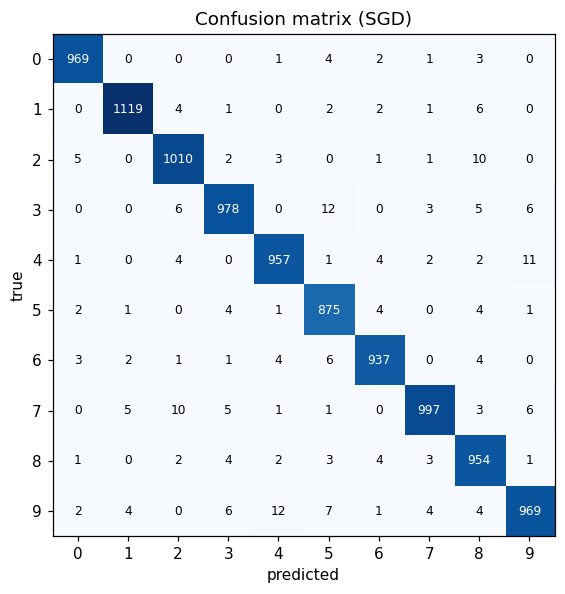

In [31]:
best_name = max(results, key=lambda n: results[n][1]["test_acc"][-1])
best = results[best_name][0]
pred = best.predict(x_test)

cm = np.zeros((10, 10), dtype=int)
np.add.at(cm, (y_test, pred), 1)

fig, ax = plt.subplots(figsize=(6.5, 5.5))
im = ax.imshow(cm, cmap="Blues"); ax.grid(False)
for i in range(10):
    for j in range(10):
        ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=8, color="white" if cm[i, j] > cm.max() / 2 else "black")
ax.set(title=f"Confusion matrix ({best_name})", xlabel="predicted", ylabel="true", xticks=range(10), yticks=range(10))
show(fig, "confusion.png")

### 7.2 Mistakes the network makes
Most are digits a human would also squint at.

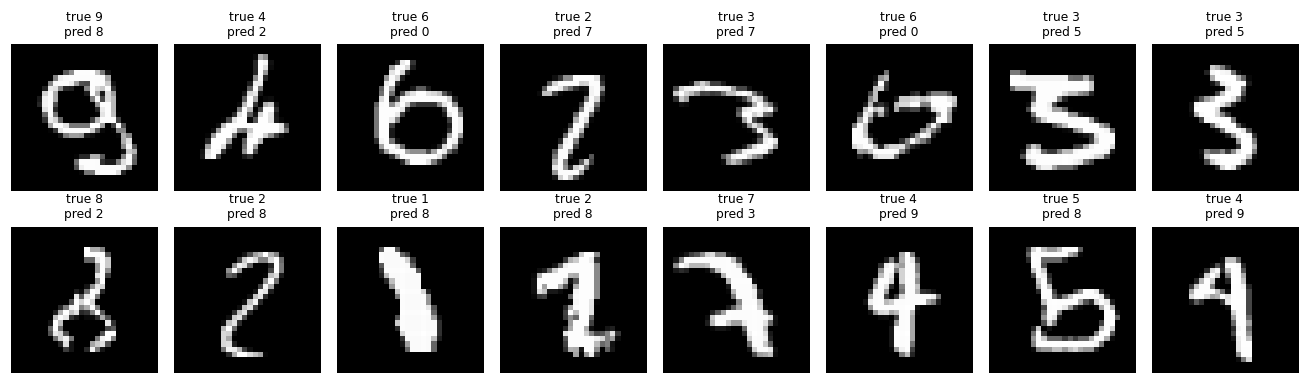

In [33]:
wrong = np.where(pred != y_test)[0][:16]
fig, axes = plt.subplots(2, 8, figsize=(12, 3.6))
for ax, i in zip(axes.ravel(), wrong):
    ax.imshow(x_test[i].reshape(SIDE, SIDE), cmap="gray"); ax.axis("off")
    ax.set_title(f"true {y_test[i]}\npred {pred[i]}", fontsize=8)
for ax in axes.ravel()[len(wrong):]: ax.axis("off")
show(fig, "mistakes.png")

### 7.3 Peek inside: first-layer weights
Each hidden neuron is a 'pattern detector' over the pixels. Its weights, reshaped to an image, show what it looks for.

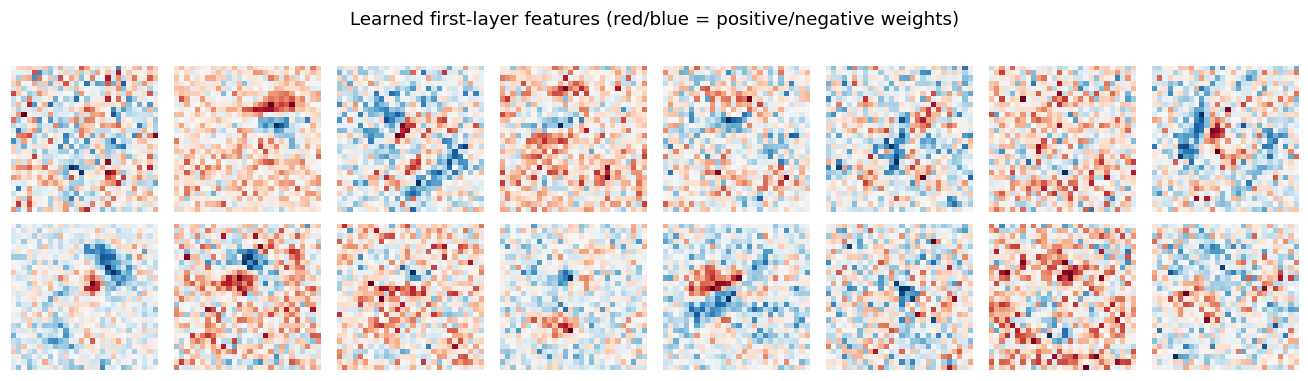

In [35]:
W1 = best.layers[0].W
fig, axes = plt.subplots(2, 8, figsize=(12, 3.6))
for ax, j in zip(axes.ravel(), range(16)):
    ax.imshow(W1[:, j].reshape(SIDE, SIDE), cmap="RdBu"); ax.axis("off")
fig.suptitle("Learned first-layer features (red/blue = positive/negative weights)")
show(fig, "weights.png")

---
## Part 8 · Break it on purpose

You understand something when you can predict how it fails. Two experiments:

**A. A one-line gradient bug.** Forget the `/ n` in the loss gradient (simulated by scaling the gradient by the batch size). The code still runs and the model still trains, but gradient checking catches it instantly.

In [37]:
print("Simulating the bug: gradient is 8x too large (batch of 8)")
worst = gradient_check(grad_scale=8.0)
print(f"\nworst relative error = {worst:.2e} -> {'caught ✅' if worst > 1e-6 else 'missed ❌'}")

Simulating the bug: gradient is 8x too large (batch of 8)
  W1: relative error = 7.78e-01  ❌
  b1: relative error = 7.78e-01  ❌
  W2: relative error = 7.78e-01  ❌
  b2: relative error = 7.78e-01  ❌

worst relative error = 7.78e-01 -> caught ✅


**B. Learning-rate sweep for SGD.** Too small crawls, about right descends, too large diverges or bounces.

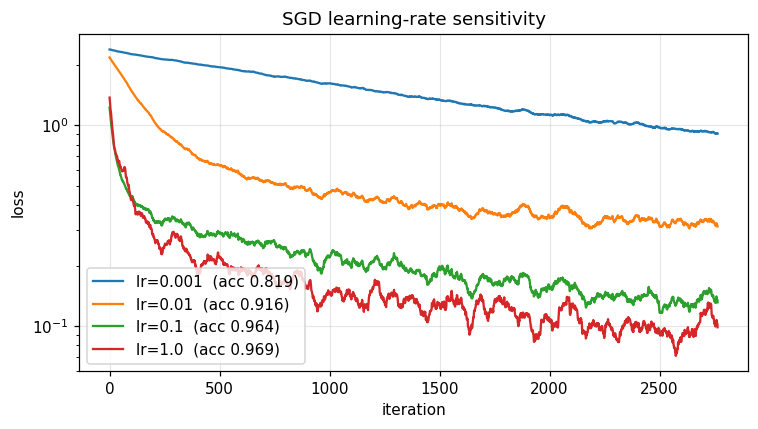

In [39]:
sweep_epochs = max(2, min(3, EPOCHS))
fig, ax = plt.subplots(figsize=(7, 4))
for lr in [0.001, 0.01, 0.1, 1.0]:
    mdl = MLP(IN_DIM, HIDDEN, 10, seed=SEED)
    h = fit(mdl, SGD(lr), data, sweep_epochs, BATCH_SIZE, SEED, log=lambda *a: None)
    k = min(50, len(h["iter_loss"]))
    ax.plot(np.convolve(h["iter_loss"], np.ones(k) / k, mode="valid"), label=f"lr={lr}  (acc {h['test_acc'][-1]:.3f})")
ax.set(title="SGD learning-rate sensitivity", xlabel="iteration", ylabel="loss", yscale="log"); ax.legend()
show(fig, "lr_sweep.png")

**More ideas:** add momentum to SGD (`SGD(0.1, momentum=0.9)`); add a hidden layer; add L2 regularization to `Linear.backward` ($dW \mathrel{+}= \lambda W$); swap ReLU for tanh and derive its backward.

---
## Part 9 · Interview cheat sheet

| Question | Short answer |
|---|---|
| Gradient of softmax-CE? | $p-\text{onehot}(y)$, divided by $N$ for a mean loss |
| Why fuse softmax and CE? | Clean gradient, and log-sum-exp avoids overflow/`log(0)` |
| Why cache in `forward`? | `backward` needs the input (Linear) or the mask (ReLU); autograd tapes do this automatically |
| Why is $dW = X^\top dY$ the right shape? | $(\text{in},N)(N,\text{out})=(\text{in},\text{out})$ |
| How do you know the gradients are right? | Central finite differences, relative error < 1e-6; central is $O(h^2)$ vs forward-difference $O(h)$ |
| Why He init? | Keeps activation variance ~constant through ReLU layers; prevents vanishing/exploding signals |
| Why does Adam need bias correction? | $m,v$ start at 0, so early estimates are biased toward 0 |
| Why mini-batches? | Less noisy than 1 sample, cheaper and more vectorizable than the full set, mild regularizing noise |
| Why `p -= ...` not `p = p - ...`? | In-place mutation changes the model's array; rebinding changes only a local name |

**Ship it:** `git init` → commit in small pieces → push → add `results/curves.png` and your real numbers to the README → tag `v0.1.0`.